***Importing Libraries***

In [ ]:
%pip install xgboost
%pip install catboost
%pip install imbalanced-learn    # for smote
%pip install matplotlib
%pip install scikit-learn
%pip install imblearn
%pip install lightgbm

In [1]:
# dataset preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split , StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# model training
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Dataset Preparation

In [62]:
%pwd

'c:\\Users\\91809\\Desktop\\GITHUB\\Customer-Satisfaction-Score(Ratings)-Predictor'

In [63]:
%cd c:\\Users\\91809\\Desktop\\GITHUB\\Customer-Satisfaction-Score(Ratings)-Predictor

c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor


In [64]:
# df = pd.read_parquet('data\cleaned_customer_support_data.parquet')
df = pd.read_parquet('data\\featureEngg.parquet')

df.head()

,channel_name,category,Sub-category,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,Respond_time,Issue_hour,Issue_dayofweek,Agent_ticket_volume,channel_shift,log_Respond_time,Respond_time_lt_1hr,Item_price_category,Query_raise_time_days
0,Outcall,Product Queries,Life Insurance,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,0.57,11,1,42,Outcall_Morning,0.451076,True,missing,100
1,Outcall,Product Queries,Product Specific Information,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,0.03,12,1,32,Outcall_Morning,0.029559,True,missing,100
2,Inbound,Order Related,Installation/demo,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,0.37,20,1,35,Inbound_Evening,0.314811,True,missing,100
3,Inbound,Returns,Reverse Pickup Enquiry,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,0.33,20,1,48,Inbound_Evening,0.285179,True,missing,100
4,Inbound,Cancellation,Not Needed,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,0.03,10,1,124,Inbound_Morning,0.029559,True,missing,100


In [65]:
X = df.drop(columns=['CSAT Score'],axis=1)
y= df['CSAT Score']

In [66]:
feature_names = X.columns.tolist()

In [67]:
# Collecting features for transformation
X_num_features = [feature for feature in X.columns if X[feature].dtype != 'category']
X_cat_features = [feature for feature in X.columns if X[feature].dtype == 'category']

numeric_transformer = StandardScaler()
ordinal_encoder = OrdinalEncoder()  # Changed from OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('Scaling the categories', ordinal_encoder, X_cat_features),
        ('Scaling the numerics', numeric_transformer, X_num_features)
    ]
)


In [68]:
preprocessor

ColumnTransformer(transformers=[('Scaling the categories', OrdinalEncoder(),
                                 ['channel_name', 'category', 'Sub-category',
                                  'Agent_name', 'Supervisor', 'Manager',
                                  'Tenure Bucket', 'Agent Shift',
                                  'channel_shift', 'Item_price_category']),
                                ('Scaling the numerics', StandardScaler(),
                                 ['Respond_time', 'Issue_hour',
                                  'Issue_dayofweek', 'Agent_ticket_volume',
                                  'log_Respond_time', 'Respond_time_lt_1hr',
                                  'Query_raise_time_days'])])

In [69]:
X= preprocessor.fit_transform(X)

In [70]:
X[0]

array([ 2.00000000e+00,  8.00000000e+00,  1.90000000e+01,  1.07200000e+03,
        2.60000000e+01,  1.00000000e+00,  4.00000000e+00,  2.00000000e+00,
        1.20000000e+01,  3.00000000e+00, -2.43728970e-01, -7.16276427e-01,
       -9.41016010e-01, -8.57645822e-01, -8.37429820e-02,  5.17904074e-01,
        4.39364239e-01])

In [71]:
X.shape

(85907, 17)

# Model Training and Testing (without SMOTE)

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2, stratify=y)
print("X_train",X_train.shape)
print("y_train",y_train.shape)
print("X_test",X_test.shape)
print("y_test",y_test.shape)

X_train (68725, 17)
y_train (68725,)
X_test (17182, 17)
y_test (17182,)


**1. Logistic Regression**

In [28]:
lr = LogisticRegression(max_iter=2000, solver='lbfgs', multi_class='multinomial', class_weight='balanced')
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("_" * 50)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4, 5])
y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3, 4, 5])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("ROC-AUC Score (macro, OVR):", roc_auc)
print("_" * 50)


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression
              precision    recall  f1-score   support

           1       0.25      0.30      0.27      2246
           2       0.02      0.20      0.04       256
           3       0.04      0.09      0.05       512
           4       0.14      0.13      0.13      2244
           5       0.75      0.57      0.65     11924

    accuracy                           0.46     17182
   macro avg       0.24      0.26      0.23     17182
weighted avg       0.57      0.46      0.50     17182

Accuracy: 0.4558258642765685
__________________________________________________
Balanced Accuracy: 0.25750428526465663
__________________________________________________
ROC-AUC Score (macro, OVR): 0.5408749468002645
__________________________________________________


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**2. Random Forest**

In [29]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train )
y_pred = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("_" * 50)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4, 5])
y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3, 4, 5])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("ROC-AUC Score (macro, OVR):", roc_auc)
print("_" * 50)

Random Forest
              precision    recall  f1-score   support

           1       0.39      0.05      0.09      2246
           2       0.00      0.00      0.00       256
           3       0.10      0.00      0.00       512
           4       0.16      0.01      0.01      2244
           5       0.70      0.98      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.27      0.21      0.18     17182
weighted avg       0.56      0.69      0.58     17182

Accuracy: 0.6895588406471889
__________________________________________________
Balanced Accuracy: 0.20820686435686406
__________________________________________________
ROC-AUC Score (macro, OVR): 0.5059471013656717
__________________________________________________


**3. XGBoost**

In [30]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train-1)
y_pred = xgb.predict(X_test)+1

print("XGBoost")
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("_" * 50)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4, 5])
y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3, 4, 5])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("ROC-AUC Score (macro, OVR):", roc_auc)
print("_" * 50)

c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:53:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
              precision    recall  f1-score   support

           1       0.44      0.11      0.17      2246
           2       0.00      0.00      0.00       256
           3       0.00      0.00      0.00       512
           4       0.15      0.00      0.00      2244
           5       0.70      0.98      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.26      0.22      0.20     17182
weighted avg       0.57      0.69      0.59     17182

Accuracy: 0.6942730764753812
__________________________________________________
Balanced Accuracy: 0.21786365973668737
__________________________________________________
ROC-AUC Score (macro, OVR): 0.5131698777096159
__________________________________________________


**4. CatBoost (suppress verbose output)**

In [31]:

cat = CatBoostClassifier(verbose=0)
cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_test)

print("CatBoost")
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("_" * 50)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4, 5])
y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3, 4, 5])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("ROC-AUC Score (macro, OVR):", roc_auc)
print("_" * 50)

CatBoost
              precision    recall  f1-score   support

           1       0.44      0.11      0.17      2246
           2       0.00      0.00      0.00       256
           3       0.00      0.00      0.00       512
           4       0.15      0.00      0.00      2244
           5       0.70      0.98      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.26      0.22      0.20     17182
weighted avg       0.57      0.69      0.59     17182

Accuracy: 0.6942730764753812
__________________________________________________
Balanced Accuracy: 0.21786365973668737
__________________________________________________
ROC-AUC Score (macro, OVR): 0.5131698777096159
__________________________________________________


# Model Training and Testing (with SMOTE onwards)

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2, stratify=y)
print("X_train",X_train.shape)
print("y_train",y_train.shape)
print("X_test",X_test.shape)
print("y_test",y_test.shape)

X_train (68725, 17)
y_train (68725,)
X_test (17182, 17)
y_test (17182,)


In [34]:
# Step 5: Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Step 6: Check class distribution
print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", pd.Series(y_train_bal).value_counts())

Before SMOTE:
 CSAT Score
5    47693
1     8984
4     8975
3     2046
2     1027
Name: count, dtype: int64
After SMOTE:
 CSAT Score
3    47693
5    47693
4    47693
1    47693
2    47693
Name: count, dtype: int64


Now, lets again apply the same models

In [35]:
lr = LogisticRegression(max_iter=2000, solver='lbfgs', multi_class='multinomial', class_weight='balanced')
lr.fit(X_train_bal, y_train_bal)
y_pred = lr.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("_" * 50)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4, 5])
y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3, 4, 5])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("ROC-AUC Score (macro, OVR):", roc_auc)
print("_" * 50)


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression
              precision    recall  f1-score   support

           1       0.24      0.35      0.28      2246
           2       0.02      0.13      0.04       256
           3       0.04      0.08      0.05       512
           4       0.14      0.21      0.17      2244
           5       0.76      0.48      0.59     11924

    accuracy                           0.41     17182
   macro avg       0.24      0.25      0.22     17182
weighted avg       0.57      0.41      0.47     17182

Accuracy: 0.4126993365149575
__________________________________________________
Balanced Accuracy: 0.2523245996896991
__________________________________________________
ROC-AUC Score (macro, OVR): 0.5376523116975
__________________________________________________


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_bal, y_train_bal )
y_pred = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("_" * 50)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4, 5])
y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3, 4, 5])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("ROC-AUC Score (macro, OVR):", roc_auc)
print("_" * 50)

Random Forest
              precision    recall  f1-score   support

           1       0.35      0.17      0.23      2246
           2       0.00      0.00      0.00       256
           3       0.04      0.00      0.01       512
           4       0.14      0.02      0.04      2244
           5       0.71      0.93      0.81     11924

    accuracy                           0.67     17182
   macro avg       0.25      0.23      0.22     17182
weighted avg       0.56      0.67      0.60     17182

Accuracy: 0.6718659061808869
__________________________________________________
Balanced Accuracy: 0.22617890244367458
__________________________________________________
ROC-AUC Score (macro, OVR): 0.5197406282015747
__________________________________________________


In [37]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_bal, y_train_bal-1)
y_pred = xgb.predict(X_test)+1

print("XGBoost")
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("_" * 50)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4, 5])
y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3, 4, 5])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("ROC-AUC Score (macro, OVR):", roc_auc)
print("_" * 50)

c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:00:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
              precision    recall  f1-score   support

           1       0.43      0.12      0.19      2246
           2       0.14      0.00      0.01       256
           3       0.00      0.00      0.00       512
           4       0.07      0.00      0.00      2244
           5       0.71      0.98      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.27      0.22      0.20     17182
weighted avg       0.56      0.69      0.59     17182

Accuracy: 0.6936328716098242
__________________________________________________
Balanced Accuracy: 0.22104543043238628
__________________________________________________
ROC-AUC Score (macro, OVR): 0.515490603397142
__________________________________________________


In [38]:
cat = CatBoostClassifier(verbose=0)
cat.fit(X_train_bal, y_train_bal)
y_pred_cat = cat.predict(X_test)

print("CatBoost")
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("_" * 50)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4, 5])
y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3, 4, 5])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("ROC-AUC Score (macro, OVR):", roc_auc)
print("_" * 50)

CatBoost
              precision    recall  f1-score   support

           1       0.43      0.12      0.19      2246
           2       0.14      0.00      0.01       256
           3       0.00      0.00      0.00       512
           4       0.07      0.00      0.00      2244
           5       0.71      0.98      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.27      0.22      0.20     17182
weighted avg       0.56      0.69      0.59     17182

Accuracy: 0.6936328716098242
__________________________________________________
Balanced Accuracy: 0.22104543043238628
__________________________________________________
ROC-AUC Score (macro, OVR): 0.515490603397142
__________________________________________________


# Changing the labels from 1-5 to 1-3

For our use case, we actually dont care if CSAT score is 4/5 or 1/2. Instead, we want to understand the major features, and make a real time predictive model, which can help us pick the customers we must focus on in present. 

In [39]:
X.shape, y.shape

((85907, 17), (85907,))

In [40]:
y.value_counts(normalize=True)*100

CSAT Score
5    69.397139
1    13.072276
4    13.059471
3     2.977639
2     1.493476
Name: proportion, dtype: float64

Okay so now i want to create a map, like from CSAT score from 1-5 to 1-3. 

In [41]:
label_mapping = {
    1:1 ,  #negative
    2:1,   #negative
    3:2,   #neutral
    4:2,   #neutral
    5:3    #positive
}

y = y.map(label_mapping)

y.value_counts(normalize=True)*100

CSAT Score
3    69.397139
2    16.037110
1    14.565751
Name: proportion, dtype: float64

In [42]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2, stratify=y)
print("X_train",X_train.shape)
print("y_train",y_train.shape)
print("X_test",X_test.shape)
print("y_test",y_test.shape)

X_train (68725, 17)
y_train (68725,)
X_test (17182, 17)
y_test (17182,)


**Applying SMOTE**

In [43]:
#  Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Step 6: Check class distribution
print("Before SMOTE:\n", y_train.value_counts(normalize=True)*100)
print("After SMOTE:\n", pd.Series(y_train_bal).value_counts(normalize=True)*100)

Before SMOTE:
 CSAT Score
3    69.396872
2    16.037832
1    14.565296
Name: proportion, dtype: float64
After SMOTE:
 CSAT Score
3    33.333333
1    33.333333
2    33.333333
Name: proportion, dtype: float64


***Lets train the model now***

In [44]:
lr = LogisticRegression(max_iter=2000, solver='lbfgs', multi_class='multinomial', class_weight='balanced')
lr.fit(X_train_bal, y_train_bal)
y_pred = lr.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("_" * 50)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3])
y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("ROC-AUC Score (macro, OVR):", roc_auc)
print("_" * 50)


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression
              precision    recall  f1-score   support

           1       0.24      0.48      0.32      2503
           2       0.17      0.22      0.19      2755
           3       0.76      0.56      0.64     11924

    accuracy                           0.49     17182
   macro avg       0.39      0.42      0.39     17182
weighted avg       0.59      0.49      0.52     17182

Accuracy: 0.4913281340938191
__________________________________________________
Balanced Accuracy: 0.4176907146612807
__________________________________________________
ROC-AUC Score (macro, OVR): 0.5657452030946327
__________________________________________________


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [45]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_bal, y_train_bal )
y_pred = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("_" * 50)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3])
y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("ROC-AUC Score (macro, OVR):", roc_auc)
print("_" * 50)

Random Forest
              precision    recall  f1-score   support

           1       0.36      0.16      0.22      2503
           2       0.20      0.03      0.05      2755
           3       0.71      0.93      0.81     11924

    accuracy                           0.68     17182
   macro avg       0.42      0.37      0.36     17182
weighted avg       0.58      0.68      0.60     17182

Accuracy: 0.6753579327202887
__________________________________________________
Balanced Accuracy: 0.3744565291033702
__________________________________________________
ROC-AUC Score (macro, OVR): 0.5316347062510278
__________________________________________________


In [46]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_bal, y_train_bal-1)
y_pred = xgb.predict(X_test)+1

print("XGBoost")
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("_" * 50)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3])
y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("ROC-AUC Score (macro, OVR):", roc_auc)
print("_" * 50)

c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:10:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
              precision    recall  f1-score   support

           1       0.45      0.13      0.20      2503
           2       0.16      0.00      0.01      2755
           3       0.71      0.97      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.44      0.37      0.34     17182
weighted avg       0.58      0.69      0.60     17182

Accuracy: 0.6941566755907345
__________________________________________________
Balanced Accuracy: 0.36794888041423385
__________________________________________________
ROC-AUC Score (macro, OVR): 0.5262452112411806
__________________________________________________


In [47]:
cat = CatBoostClassifier(verbose=0)
cat.fit(X_train_bal, y_train_bal)
y_pred_cat = cat.predict(X_test)

print("CatBoost")
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("_" * 50)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3])
y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("ROC-AUC Score (macro, OVR):", roc_auc)
print("_" * 50)

CatBoost
              precision    recall  f1-score   support

           1       0.45      0.13      0.20      2503
           2       0.16      0.00      0.01      2755
           3       0.71      0.97      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.44      0.37      0.34     17182
weighted avg       0.58      0.69      0.60     17182

Accuracy: 0.6941566755907345
__________________________________________________
Balanced Accuracy: 0.36794888041423385
__________________________________________________
ROC-AUC Score (macro, OVR): 0.5262452112411806
__________________________________________________


**Ensembling models**

In [48]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# -------------------- Shifted Labels for XGBoost --------------------
# XGBoost requires 0-based class labels
y_train_shifted = y_train_bal - 1
y_test_shifted = y_test - 1

# -------------------- Define Models --------------------
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
cat = CatBoostClassifier(verbose=0, random_state=42)

# -------------------- Fit Individually --------------------
xgb.fit(X_train_bal, y_train_shifted)
cat.fit(X_train_bal, y_train_bal)

# -------------------- Predict Individually --------------------
y_pred_xgb = xgb.predict(X_test) + 1   # Add 1 to shift back to original label
y_pred_cat = cat.predict(X_test)

# -------------------- Voting Ensemble --------------------
voting_clf = VotingClassifier(estimators=[
    ('xgb', xgb),
    ('cat', cat)
], voting='soft')  # Use 'soft' if models support predict_proba()

voting_clf.fit(X_train_bal, y_train_shifted)  # XGBoost needs shifted labels

# -------------------- Predict with Ensemble --------------------
y_pred_ens = voting_clf.predict(X_test) + 1  # Convert back to original label (1, 2, 3)

# -------------------- Evaluation --------------------
print("📌 Ensemble (XGBoost + CatBoost)")
print(classification_report(y_test, y_pred_ens, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred_ens))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_ens))
print("_" * 50)

# --- ROC-AUC ---
y_test_bin = label_binarize(y_test, classes=[1, 2, 3])
y_pred_bin = label_binarize(y_pred_ens, classes=[1, 2, 3])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("ROC-AUC Score (macro, OVR):", roc_auc)
print("_" * 50)


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:12:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:14:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📌 Ensemble (XGBoost + CatBoost)
              precision    recall  f1-score   support

           1       0.45      0.13      0.20      2503
           2       0.22      0.00      0.00      2755
           3       0.71      0.97      0.82     11924

    accuracy                           0.70     17182
   macro avg       0.46      0.37      0.34     17182
weighted avg       0.59      0.70      0.60     17182

Accuracy: 0.6954370853218484
__________________________________________________
Balanced Accuracy: 0.36900912414388104
__________________________________________________
ROC-AUC Score (macro, OVR): 0.5271914420344995
__________________________________________________


In [49]:
from lightgbm import LGBMClassifier

# -------------------- Define Models --------------------
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
cat = CatBoostClassifier(verbose=0, random_state=42)
lgb = LGBMClassifier(random_state=42)

# -------------------- Shift Labels for XGBoost --------------------
y_train_shifted = y_train_bal - 1
y_test_shifted = y_test - 1

# -------------------- Fit Individually (Optional but Good for Debugging) --------------------
xgb.fit(X_train_bal, y_train_shifted)
cat.fit(X_train_bal, y_train_bal)
lgb.fit(X_train_bal, y_train_bal)

# -------------------- Voting Ensemble --------------------
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', xgb),
        ('cat', cat),
        ('lgb', lgb)
    ],
    voting='soft'  # All support predict_proba
)

voting_clf.fit(X_train_bal, y_train_shifted)  # Only XGBoost cares about shifted labels

# -------------------- Predict --------------------
y_pred_ens = voting_clf.predict(X_test) + 1  # Shift back to original label (1, 2, 3)

# -------------------- Evaluation --------------------
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

print("📌 Ensemble (XGBoost + CatBoost + LightGBM)")
print(classification_report(y_test, y_pred_ens, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred_ens))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_ens))

# --- ROC-AUC ---
y_test_bin = label_binarize(y_test, classes=[1, 2, 3])
y_pred_bin = label_binarize(y_pred_ens, classes=[1, 2, 3])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("_" * 50)
print("ROC-AUC Score (macro, OVR):", roc_auc)


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:17:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038539 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4331
[LightGBM] [Info] Number of data points in the train set: 143079, number of used features: 17
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:19:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040539 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4331
[LightGBM] [Info] Number of data points in the train set: 143079, number of used features: 17
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


📌 Ensemble (XGBoost + CatBoost + LightGBM)
              precision    recall  f1-score   support

           1       0.46      0.12      0.19      2503
           2       0.33      0.00      0.00      2755
           3       0.71      0.98      0.82     11924

    accuracy                           0.70     17182
   macro avg       0.50      0.37      0.34     17182
weighted avg       0.61      0.70      0.60     17182

Accuracy: 0.6963682923990222
__________________________________________________
Balanced Accuracy: 0.36579810961959525
__________________________________________________
ROC-AUC Score (macro, OVR): 0.5246714234272752


# Pushing ROC AUC from 0.55 to 0.8

**Trying a better SMOTE variant**

In [72]:
label_mapping = {
    1:1 ,  #negative
    2:1,   #negative
    3:2,   #neutral
    4:2,   #neutral
    5:3    #positive
}

y = y.map(label_mapping)

y.value_counts(normalize=True)*100

CSAT Score
3    69.397139
2    16.037110
1    14.565751
Name: proportion, dtype: float64

In [73]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2, stratify=y)

#  Apply SMOTE on training data only
smk = SMOTETomek(random_state=42)
X_train_bal, y_train_bal  = smk.fit_resample(X_train, y_train)

# Step 6: Check class distribution
print("Before SMOTE:\n", y_train.value_counts(normalize=True)*100)
print("After SMOTE:\n", pd.Series(y_train_bal).value_counts(normalize=True)*100)

Before SMOTE:
 CSAT Score
3    69.396872
2    16.037832
1    14.565296
Name: proportion, dtype: float64
After SMOTE:
 CSAT Score
1    33.817951
2    33.317983
3    32.864066
Name: proportion, dtype: float64


**Logistic Regression** 

In [74]:
lr = LogisticRegression(max_iter=2000, solver='lbfgs', multi_class='multinomial', class_weight='balanced')
lr.fit(X_train_bal, y_train_bal)
y_pred = lr.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("_" * 50)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3])
y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("ROC-AUC Score (macro, OVR):", roc_auc)
print("_" * 50)


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression
              precision    recall  f1-score   support

           1       0.24      0.46      0.32      2503
           2       0.17      0.23      0.20      2755
           3       0.76      0.56      0.64     11924

    accuracy                           0.49     17182
   macro avg       0.39      0.42      0.39     17182
weighted avg       0.59      0.49      0.52     17182

Accuracy: 0.4893493190548248
__________________________________________________
Balanced Accuracy: 0.4156305104393579
__________________________________________________
ROC-AUC Score (macro, OVR): 0.5644822077190731
__________________________________________________


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Random Forest**

In [75]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_bal, y_train_bal )
y_pred = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("_" * 50)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3])
y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("ROC-AUC Score (macro, OVR):", roc_auc)
print("_" * 50)

Random Forest
              precision    recall  f1-score   support

           1       0.35      0.16      0.22      2503
           2       0.21      0.03      0.05      2755
           3       0.71      0.93      0.81     11924

    accuracy                           0.67     17182
   macro avg       0.42      0.37      0.36     17182
weighted avg       0.58      0.67      0.60     17182

Accuracy: 0.6743103247584682
__________________________________________________
Balanced Accuracy: 0.3734272487528178
__________________________________________________
ROC-AUC Score (macro, OVR): 0.5305123894885693
__________________________________________________


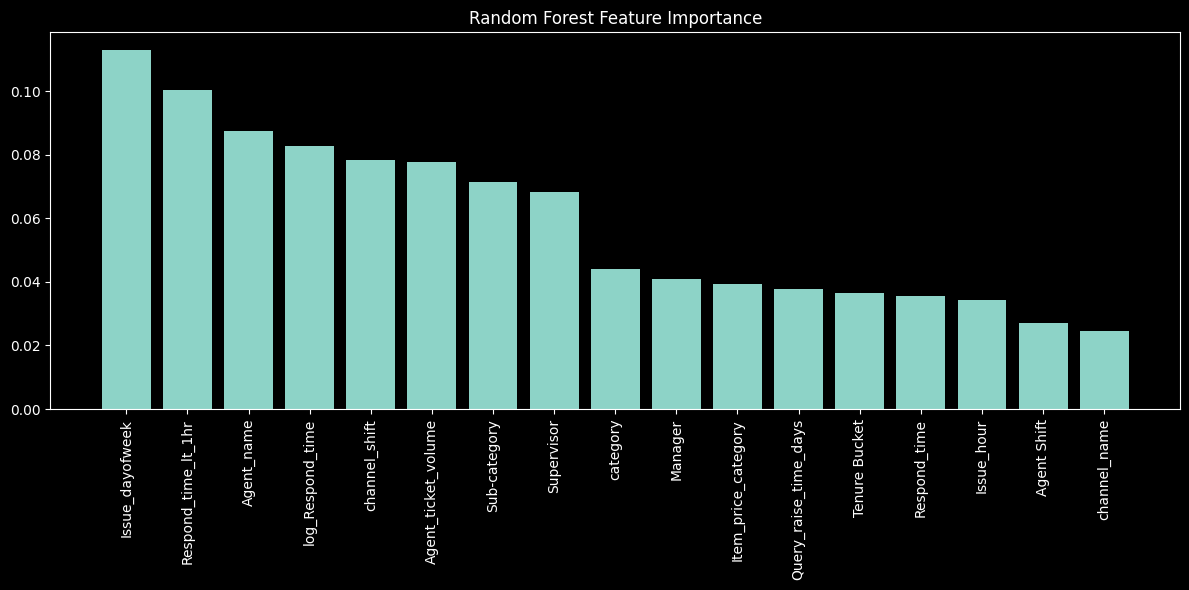

In [76]:
# Assuming rf is your trained RandomForestClassifier
rf_importances = rf.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Random Forest Feature Importance")
plt.bar(range(len(rf_importances)), rf_importances[indices_rf])
plt.xticks(range(len(rf_importances)), np.array(feature_names)[indices_rf], rotation=90)
plt.tight_layout()
plt.show()



**XGBOOST**

In [77]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_bal, y_train_bal-1)
y_pred = xgb.predict(X_test)+1

print("XGBoost")
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("_" * 50)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3])
y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("ROC-AUC Score (macro, OVR):", roc_auc)
print("_" * 50)

c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:34:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
              precision    recall  f1-score   support

           1       0.44      0.13      0.20      2503
           2       0.17      0.00      0.01      2755
           3       0.71      0.97      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.44      0.37      0.34     17182
weighted avg       0.58      0.69      0.60     17182

Accuracy: 0.6949714817832615
__________________________________________________
Balanced Accuracy: 0.36834024796427295
__________________________________________________
ROC-AUC Score (macro, OVR): 0.5270069234180983
__________________________________________________


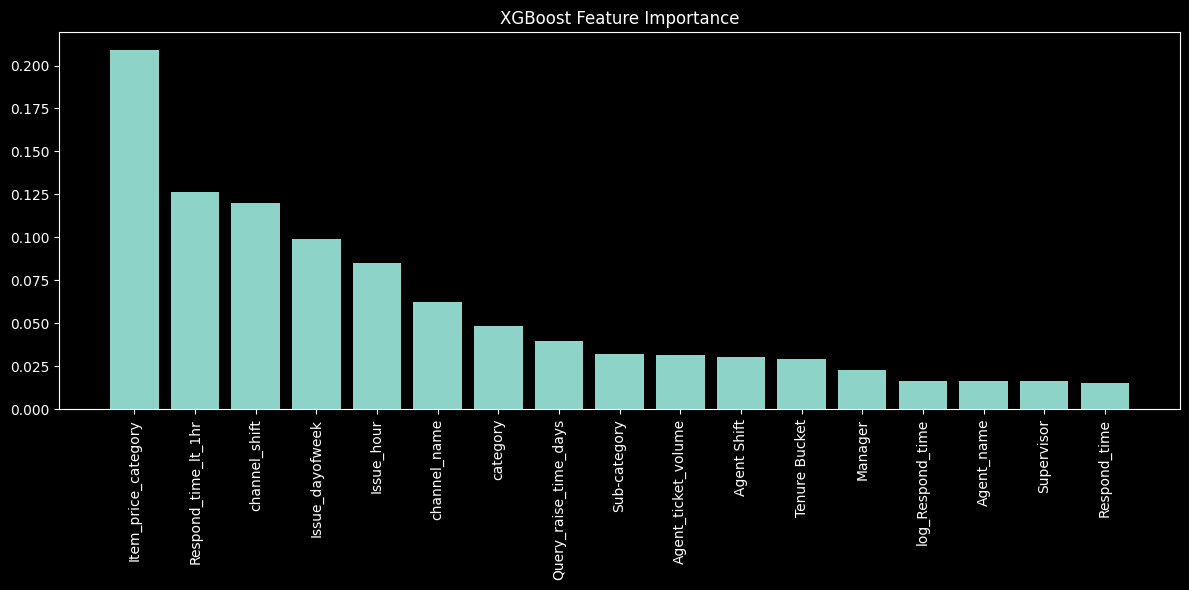

In [78]:
xgb_importances = xgb.feature_importances_
indices_xgb = np.argsort(xgb_importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("XGBoost Feature Importance")
plt.bar(range(len(xgb_importances)), xgb_importances[indices_xgb])
plt.xticks(range(len(xgb_importances)), np.array(feature_names)[indices_xgb], rotation=90)
plt.tight_layout()
plt.show()


***Boooster Based- more accurate***

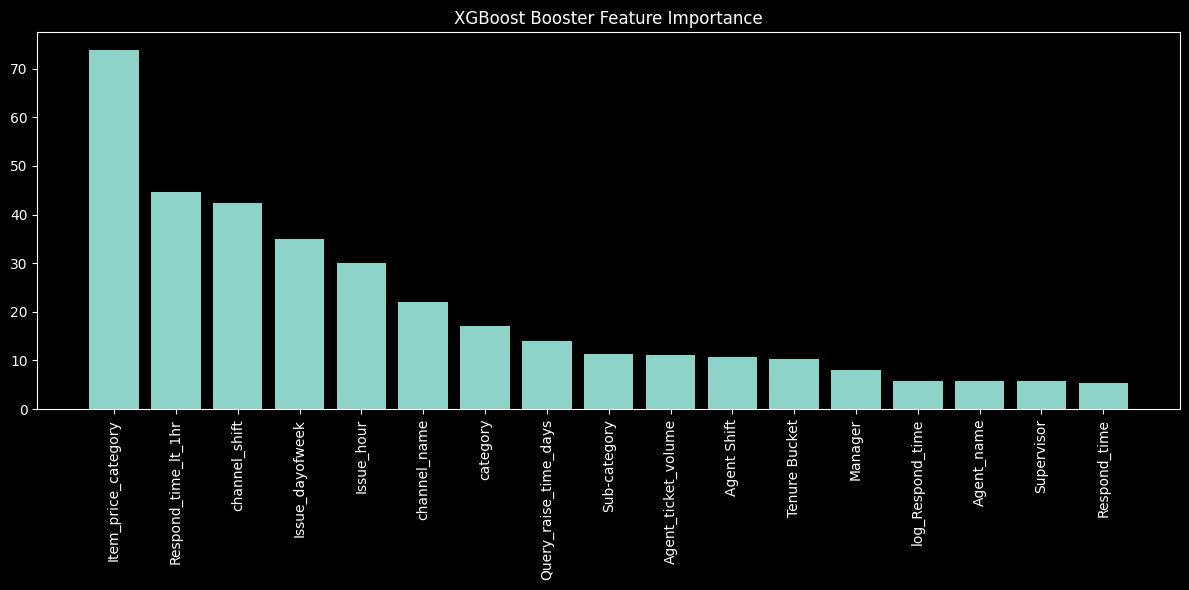

In [79]:
booster = xgb.get_booster()
importance_dict = booster.get_score(importance_type='gain')  # or 'weight', 'cover'
# Create array of importances aligned with feature_names
xgb_importances = [importance_dict.get(f'f{i}', 0) for i in range(len(feature_names))]
indices_xgb = np.argsort(xgb_importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("XGBoost Booster Feature Importance")
plt.bar(range(len(xgb_importances)), np.array(xgb_importances)[indices_xgb])
plt.xticks(range(len(xgb_importances)), np.array(feature_names)[indices_xgb], rotation=90)
plt.tight_layout()
plt.show()


**Catboost**

In [80]:
cat = CatBoostClassifier(verbose=0)
cat.fit(X_train_bal, y_train_bal)
y_pred_cat = cat.predict(X_test)

print("CatBoost")
print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("_" * 50)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3])
y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("ROC-AUC Score (macro, OVR):", roc_auc)
print("_" * 50)

CatBoost
              precision    recall  f1-score   support

           1       0.44      0.13      0.20      2503
           2       0.17      0.00      0.01      2755
           3       0.71      0.97      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.44      0.37      0.34     17182
weighted avg       0.58      0.69      0.60     17182

Accuracy: 0.6949714817832615
__________________________________________________
Balanced Accuracy: 0.36834024796427295
__________________________________________________
ROC-AUC Score (macro, OVR): 0.5270069234180983
__________________________________________________


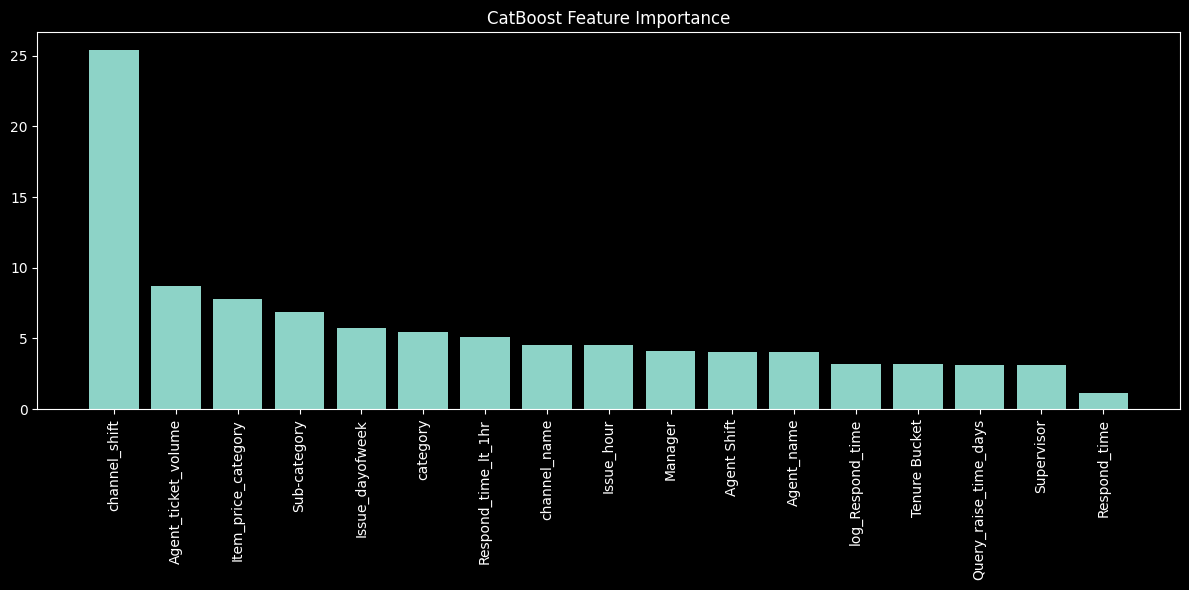

In [81]:
cat_importances = cat.get_feature_importance()
indices_cat = np.argsort(cat_importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("CatBoost Feature Importance")
plt.bar(range(len(cat_importances)), np.array(cat_importances)[indices_cat])
plt.xticks(range(len(cat_importances)), np.array(feature_names)[indices_cat], rotation=90)
plt.tight_layout()
plt.show()


**Ensemble (XGBoost + CatBoost + LightGBM) - Voting Classifier**

In [82]:
from lightgbm import LGBMClassifier

# -------------------- Define Models --------------------
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
cat = CatBoostClassifier(verbose=0, random_state=42)
lgb = LGBMClassifier(random_state=42)

# -------------------- Shift Labels for XGBoost --------------------
y_train_shifted = y_train_bal - 1
y_test_shifted = y_test - 1

# -------------------- Fit Individually (Optional but Good for Debugging) --------------------
xgb.fit(X_train_bal, y_train_shifted)
cat.fit(X_train_bal, y_train_bal)
lgb.fit(X_train_bal, y_train_bal)

# -------------------- Voting Ensemble --------------------
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', xgb),
        ('cat', cat),
        ('lgb', lgb)
    ],
    voting='soft'  # All support predict_proba
)

voting_clf.fit(X_train_bal, y_train_shifted)  # Only XGBoost cares about shifted labels

# -------------------- Predict --------------------
y_pred_ens = voting_clf.predict(X_test) + 1  # Shift back to original label (1, 2, 3)

# -------------------- Evaluation --------------------
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

print("📌 Ensemble (XGBoost + CatBoost + LightGBM)")
print(classification_report(y_test, y_pred_ens, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred_ens))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_ens))

# --- ROC-AUC ---
y_test_bin = label_binarize(y_test, classes=[1, 2, 3])
y_pred_bin = label_binarize(y_pred_ens, classes=[1, 2, 3])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("_" * 50)
print("ROC-AUC Score (macro, OVR):", roc_auc)


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:36:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4332
[LightGBM] [Info] Number of data points in the train set: 136809, number of used features: 17
[LightGBM] [Info] Start training from score -1.084178
[LightGBM] [Info] Start training from score -1.099073
[LightGBM] [Info] Start training from score -1.112790


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:38:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4332
[LightGBM] [Info] Number of data points in the train set: 136809, number of used features: 17
[LightGBM] [Info] Start training from score -1.084178
[LightGBM] [Info] Start training from score -1.099073
[LightGBM] [Info] Start training from score -1.112790


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


📌 Ensemble (XGBoost + CatBoost + LightGBM)
              precision    recall  f1-score   support

           1       0.47      0.12      0.19      2503
           2       0.20      0.00      0.00      2755
           3       0.71      0.98      0.82     11924

    accuracy                           0.70     17182
   macro avg       0.46      0.37      0.34     17182
weighted avg       0.59      0.70      0.60     17182

Accuracy: 0.6967756954952857
__________________________________________________
Balanced Accuracy: 0.3668599057746022
__________________________________________________
ROC-AUC Score (macro, OVR): 0.525444945909095


**📌 Stacking Ensemble (XGBoost + CatBoost + LightGBM ➜ Logistic Regression)**

In [83]:
# -------------------- Define Base Models --------------------
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
cat = CatBoostClassifier(verbose=0, random_state=42)
lgb = LGBMClassifier(random_state=42)

# -------------------- Shift labels for XGBoost --------------------
y_train_shifted = y_train_bal - 1
y_test_shifted = y_test - 1

# -------------------- Stacking Classifier --------------------
stacking_clf = StackingClassifier(
    estimators=[
        ('xgb', xgb),
        ('cat', cat),
        ('lgb', lgb)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    passthrough=True,  # optional: pass original features along with base model predictions
    cv=5,
    n_jobs=-1
)

# -------------------- Fit --------------------
stacking_clf.fit(X_train_bal, y_train_shifted)

# -------------------- Predict --------------------
y_pred_stack = stacking_clf.predict(X_test) + 1  # Shift back to original label (1, 2, 3)

# -------------------- Evaluation --------------------
print("📌 Stacking Ensemble (XGBoost + CatBoost + LightGBM ➜ Logistic Regression)")
print(classification_report(y_test, y_pred_stack, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print("_" * 50)
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_stack))

# --- ROC-AUC ---
y_test_bin = label_binarize(y_test, classes=[1, 2, 3])
y_pred_bin = label_binarize(y_pred_stack, classes=[1, 2, 3])
roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')
print("_" * 50)
print("ROC-AUC Score (macro, OVR):", roc_auc)


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


📌 Stacking Ensemble (XGBoost + CatBoost + LightGBM ➜ Logistic Regression)
              precision    recall  f1-score   support

           1       0.35      0.32      0.34      2503
           2       0.21      0.04      0.07      2755
           3       0.73      0.88      0.80     11924

    accuracy                           0.67     17182
   macro avg       0.43      0.42      0.40     17182
weighted avg       0.59      0.67      0.62     17182

Accuracy: 0.6652892561983471
__________________________________________________
Balanced Accuracy: 0.41534846091747163
__________________________________________________
ROC-AUC Score (macro, OVR): 0.5649002089010213


**Trying with Kfold Validations**

In [84]:
# Initialize model and stratified K-fold
lr = LogisticRegression(max_iter=2000, solver='lbfgs', multi_class='multinomial', class_weight='balanced')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smk = SMOTETomek(random_state=42)

# To collect metrics
accuracies = []
balanced_accuracies = []
roc_aucs = []

fold = 1
for train_idx, test_idx in skf.split(X, y):
    print(f"\n===== Fold {fold} =====")
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Apply SMOTE on training only
    X_train_bal, y_train_bal = smk.fit_resample(X_train, y_train)

    # Train model
    lr.fit(X_train_bal, y_train_bal)

    # Predict on test
    y_pred = lr.predict(X_test)

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    y_test_bin = label_binarize(y_test, classes=[1, 2, 3])
    y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3])
    roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')

    # Store metrics
    accuracies.append(acc)
    balanced_accuracies.append(bal_acc)
    roc_aucs.append(roc_auc)

    print(classification_report(y_test, y_pred, zero_division=0))
    print(f"Accuracy: {acc:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"ROC AUC (macro): {roc_auc:.4f}")
    
    fold += 1

# Final Average Results
print("\n===== Overall Performance =====")
print(f"Mean Accuracy: {np.mean(accuracies):.4f}")
print(f"Mean Balanced Accuracy: {np.mean(balanced_accuracies):.4f}")
print(f"Mean ROC-AUC Score: {np.mean(roc_aucs):.4f}")


===== Fold 1 =====


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           1       0.24      0.46      0.32      2503
           2       0.17      0.22      0.19      2755
           3       0.75      0.55      0.64     11924

    accuracy                           0.49     17182
   macro avg       0.39      0.41      0.38     17182
weighted avg       0.58      0.49      0.52     17182

Accuracy: 0.4870
Balanced Accuracy: 0.4120
ROC AUC (macro): 0.5613

===== Fold 2 =====


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           1       0.24      0.47      0.31      2503
           2       0.16      0.20      0.18      2755
           3       0.75      0.55      0.64     11924

    accuracy                           0.48     17182
   macro avg       0.38      0.41      0.38     17182
weighted avg       0.58      0.48      0.52     17182

Accuracy: 0.4839
Balanced Accuracy: 0.4087
ROC AUC (macro): 0.5595

===== Fold 3 =====


...

c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           1       0.24      0.46      0.32      2502
           2       0.17      0.23      0.19      2756
           3       0.75      0.54      0.63     11923

    accuracy                           0.48     17181
   macro avg       0.39      0.41      0.38     17181
weighted avg       0.58      0.48      0.51     17181

Accuracy: 0.4799
Balanced Accuracy: 0.4105
ROC AUC (macro): 0.5600

===== Fold 5 =====


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           1       0.25      0.48      0.33      2503
           2       0.16      0.21      0.18      2755
           3       0.75      0.56      0.64     11923

    accuracy                           0.49     17181
   macro avg       0.39      0.41      0.38     17181
weighted avg       0.58      0.49      0.52     17181

Accuracy: 0.4889
Balanced Accuracy: 0.4143
ROC AUC (macro): 0.5619

===== Overall Performance =====
Mean Accuracy: 0.4884
Mean Balanced Accuracy: 0.4127
Mean ROC-AUC Score: 0.5616


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [85]:
# Initialize model, SMOTETomek, StratifiedKFold
xgb = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=3,
    use_label_encoder=False,
    random_state=42
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smk = SMOTETomek(random_state=42)

# To collect metrics
accuracies = []
balanced_accuracies = []
roc_aucs = []

fold = 1
for train_idx, test_idx in skf.split(X, y):
    print(f"\n===== Fold {fold} =====")
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Apply SMOTETomek only on training data
    X_train_bal, y_train_bal = smk.fit_resample(X_train, y_train)

    # Train the model
    xgb.fit(X_train_bal, y_train_bal-1)

    # Predict
    y_pred = xgb.predict(X_test)+1

    # Evaluation
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    y_test_bin = label_binarize(y_test, classes=[1, 2, 3])
    y_pred_bin = label_binarize(y_pred, classes=[1, 2, 3])
    roc_auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr', average='macro')

    # Store metrics
    accuracies.append(acc)
    balanced_accuracies.append(bal_acc)
    roc_aucs.append(roc_auc)

    print(classification_report(y_test, y_pred, zero_division=0))
    print(f"Accuracy: {acc:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"ROC AUC (macro): {roc_auc:.4f}")

    fold += 1

# Final Results
print("\n===== Overall Performance =====")
print(f"Mean Accuracy: {np.mean(accuracies):.4f}")
print(f"Mean Balanced Accuracy: {np.mean(balanced_accuracies):.4f}")
print(f"Mean ROC-AUC Score: {np.mean(roc_aucs):.4f}")


===== Fold 1 =====


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:56:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           1       0.43      0.13      0.20      2503
           2       0.30      0.00      0.01      2755
           3       0.71      0.97      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.48      0.37      0.34     17182
weighted avg       0.60      0.69      0.60     17182

Accuracy: 0.6933
Balanced Accuracy: 0.3675
ROC AUC (macro): 0.5259

===== Fold 2 =====


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:57:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           1       0.44      0.12      0.19      2503
           2       0.17      0.00      0.01      2755
           3       0.71      0.97      0.82     11924

    accuracy                           0.69     17182
   macro avg       0.44      0.37      0.34     17182
weighted avg       0.58      0.69      0.60     17182

Accuracy: 0.6945
Balanced Accuracy: 0.3667
ROC AUC (macro): 0.5256

===== Fold 3 =====


...

              precision    recall  f1-score   support

           1       0.44      0.12      0.19      2502
           2       0.17      0.00      0.01      2756
           3       0.71      0.97      0.82     11923

    accuracy                           0.69     17181
   macro avg       0.44      0.37      0.34     17181
weighted avg       0.58      0.69      0.60     17181

Accuracy: 0.6940
Balanced Accuracy: 0.3663
ROC AUC (macro): 0.5253

===== Fold 4 =====


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:58:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           1       0.43      0.14      0.21      2502
           2       0.25      0.00      0.01      2756
           3       0.71      0.97      0.82     11923

    accuracy                           0.69     17181
   macro avg       0.46      0.37      0.34     17181
weighted avg       0.59      0.69      0.60     17181

Accuracy: 0.6935
Balanced Accuracy: 0.3703
ROC AUC (macro): 0.5282

===== Fold 5 =====


c:\Users\91809\Desktop\GITHUB\Customer-Satisfaction-Score(Ratings)-Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:59:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           1       0.46      0.13      0.21      2503
           2       0.33      0.00      0.01      2755
           3       0.71      0.98      0.82     11923

    accuracy                           0.70     17181
   macro avg       0.50      0.37      0.35     17181
weighted avg       0.61      0.70      0.60     17181

Accuracy: 0.6973
Balanced Accuracy: 0.3710
ROC AUC (macro): 0.5290

===== Overall Performance =====
Mean Accuracy: 0.6945
Mean Balanced Accuracy: 0.3684
Mean ROC-AUC Score: 0.5268


# HyperParameter Training

# SHap- Model Explainer

# Insights/ Suggestion to Flipkart Team

**1. Reducing the gap between customers and their order/products**


*   we  can give more accurate information of the product like approx gps to the customer.
*   on the day of delivery, we can update the customer with agent info e.g. approx location and number of items still left to be delivery.


*   Instead of sending a whatsapp mssg, saying your item will be deilvered today by mr. X and contact no.; we can make it more personalised.
*   For sharing these info we can make use of Agentic AI, chatbots, RAGs systems.

**2. Rewarding the customers**



*   We should reward the customer with valuable feedback/ reviews. Price of gift doesn't matter, even a gift Card, pesonalised email or certificates showing their valuable contribution to flipkart would suffice.
*   We should also reward our loyal customers, send them gifts and show them how we care about them.



**3. Reducing the gap between customers and Flipkart**



*   We can show how we treat their order carefully and ensure it reaches safely to them.
*   we can invite some lucky customers for Flipkart tour.

*   We should try to make sure, we can be like a family to our customers.

*   In long terms, we can cultivate sense of motherhood in us Indians, so that we prefer our Indian products by choice and pride.



# Future Works

- Collect more data; better features.
- Try it as anomaly detection; 2 classifier one for low score, other for medium score and rest fallback to high score.